## Needleman-Wunsch-Alignment


This algorithm is used to calculate a biologically relevant global alignment score of the amino acid sequences. Advantage: Insertions or deletions at the beginning or end of the alignment are taken into account in the score calculation. It explores all possible alignments and finds the best possible match based on a scoring matrix (like BLOSUM62).
Gaps are penalized (opening and extending), allowing flexible alignment while still rewarding similarity.

In [2]:
import pandas as pd
from Bio import pairwise2
from Bio.Align import substitution_matrices
import numpy as np

# 1. Scoring-Matrix laden
blosum62 = substitution_matrices.load("BLOSUM62")

# 2. TSV-Dateien einlesen
sars_df = pd.read_csv(r"C:\Users\clara\group04-team02\data cleanup\sars_cov2_cdr_seq.tsv", sep="\t")
human_df = pd.read_csv(r"C:\Users\clara\group04-team02\data cleanup\human_cdr_seq.tsv", sep="\t")
influenza_df = pd.read_csv(r"C:\Users\clara\group04-team02\data cleanup\influenza_cdr_seq.tsv", sep="\t")

# 3. Alle Sequenzen extrahieren
def extract_cdrs(df, label):
    cdrs = []
    for _, row in df.iterrows():
        cdrs.append({
            "id": f"{label}_{row['pdb']}",
            "CDR_H1": row["CDR_H1"],
            "CDR_H2": row["CDR_H2"],
            "CDR_H3": row["CDR_H3"]
        })
    return cdrs

sars_cdrs = extract_cdrs(sars_df, "SARS")
human_cdrs = extract_cdrs(human_df, "Human")
influenza_cdrs = extract_cdrs(influenza_df, "Flu")

# 4. Alle Sequenzen in einer Liste sammeln
all_cdrs = sars_cdrs + human_cdrs + influenza_cdrs
all_ids = [entry["id"] for entry in all_cdrs]

# 5. Alignment-Funktion
def align_pair(seq1, seq2):
    aln = pairwise2.align.globalds(seq1, seq2, blosum62, -10, -0.5, one_alignment_only=True)
    score = aln[0].score
    return score

# 6. Ergebnisse speichern
cdr_types = ["CDR_H1", "CDR_H2", "CDR_H3"]

# Dictionaries für Matrix-DataFrames und Long-Format
matrix_results = {}
long_format_rows = []

for cdr in cdr_types:
    # Leere Score-Matrix
    score_matrix = np.zeros((len(all_ids), len(all_ids)))
    
    print(f"\n=== Processing {cdr} ===")
    
    # Alle Paarungen
    for i in range(len(all_cdrs)):
        for j in range(len(all_cdrs)):
            id1 = all_ids[i]
            id2 = all_ids[j]
            seq1 = all_cdrs[i][cdr]
            seq2 = all_cdrs[j][cdr]
            score = align_pair(seq1, seq2)
            
            score_matrix[i, j] = score
            
            if j > i:
                # Long format nur obere Hälfte
                long_format_rows.append({
                    "CDR": cdr,
                    "ID1": id1,
                    "ID2": id2,
                    "Score": score
                })
    
    # Speichern in DataFrame
    df_matrix = pd.DataFrame(score_matrix, index=all_ids, columns=all_ids)
    matrix_results[cdr] = df_matrix
    
    # In TSV-Datei schreiben
    outfile = f"{cdr.lower()}_alignment_matrix.tsv"
    df_matrix.to_csv(outfile, sep="\t")
    print(f"Saved matrix to {outfile}")

# 7. Long-Format TSV speichern
df_long = pd.DataFrame(long_format_rows)
df_long.to_csv("all_cdr_alignment_long.tsv", sep="\t", index=False)
print("Saved long-format file to all_cdr_alignment_long.tsv")



=== Processing CDR_H1 ===
Saved matrix to cdr_h1_alignment_matrix.tsv

=== Processing CDR_H2 ===
Saved matrix to cdr_h2_alignment_matrix.tsv

=== Processing CDR_H3 ===
Saved matrix to cdr_h3_alignment_matrix.tsv
Saved long-format file to all_cdr_alignment_long.tsv


### PCA

Für eine PCA, ist es sinnvoll die Alignment-Scores in Distanzen umzuwandeln.
Distance=max(Score)−Score

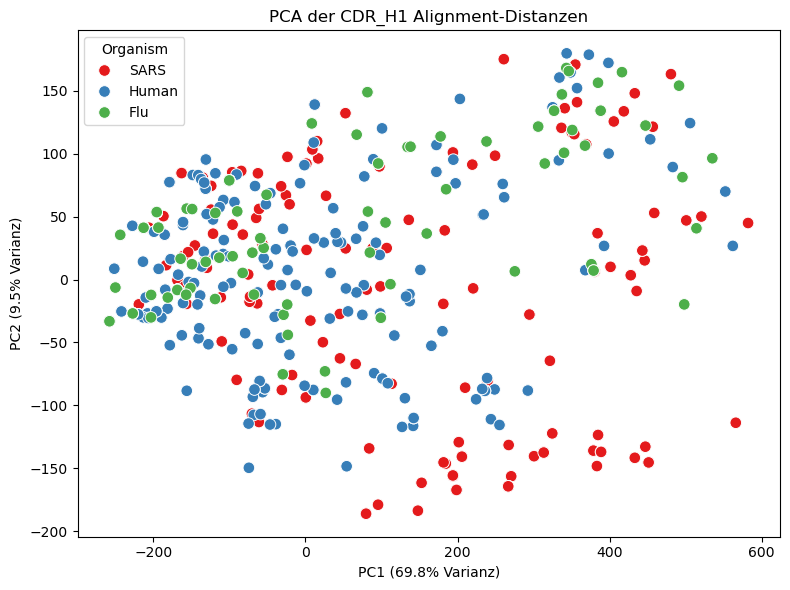

In [5]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Alignment-Score-Matrix einlesen
# Falls du schon `matrix_results` aus deinem Code hast, kannst du stattdessen direkt:
# score_df = matrix_results["CDR_H2"]

score_df = pd.read_csv("cdr_h1_alignment_matrix.tsv", sep="\t", index_col=0)

# 2️⃣ Distanzmatrix berechnen
# Wir nehmen als Distanz: max(Score) - Score
max_score = score_df.values.max()
distance_matrix = max_score - score_df.values

# 3️⃣ PCA berechnen
pca = PCA(n_components=2)
pcs = pca.fit_transform(distance_matrix)

# 4️⃣ DataFrame für Plot vorbereiten
ids = score_df.index.tolist()
organisms = [id.split("_")[0] for id in ids]

pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "ID": ids,
    "Organism": organisms
})

# 5️⃣ Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Organism",  # Farben nach Organismus
    palette="Set1",
    s=70
)
plt.title("PCA der CDR_H1 Alignment-Distanzen")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.legend(title="Organism")
plt.tight_layout()
plt.show()


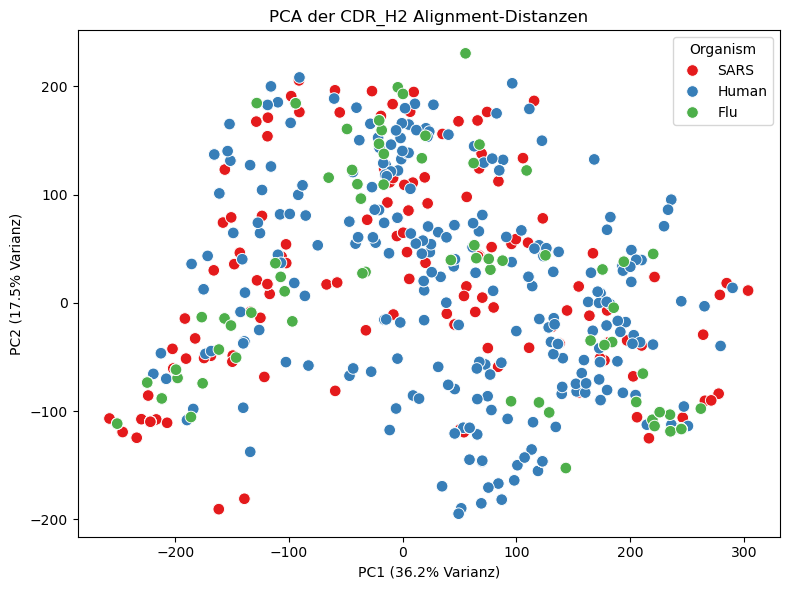

In [6]:
# 1️⃣ Alignment-Score-Matrix einlesen
# Falls du schon `matrix_results` aus deinem Code hast, kannst du stattdessen direkt:
# score_df = matrix_results["CDR_H2"]

score_df = pd.read_csv("cdr_h2_alignment_matrix.tsv", sep="\t", index_col=0)

# 2️⃣ Distanzmatrix berechnen
# Wir nehmen als Distanz: max(Score) - Score
max_score = score_df.values.max()
distance_matrix = max_score - score_df.values

# 3️⃣ PCA berechnen
pca = PCA(n_components=2)
pcs = pca.fit_transform(distance_matrix)

# 4️⃣ DataFrame für Plot vorbereiten
ids = score_df.index.tolist()
organisms = [id.split("_")[0] for id in ids]

pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "ID": ids,
    "Organism": organisms
})

# 5️⃣ Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Organism",  # Farben nach Organismus
    palette="Set1",
    s=70
)
plt.title("PCA der CDR_H2 Alignment-Distanzen")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.legend(title="Organism")
plt.tight_layout()
plt.show()


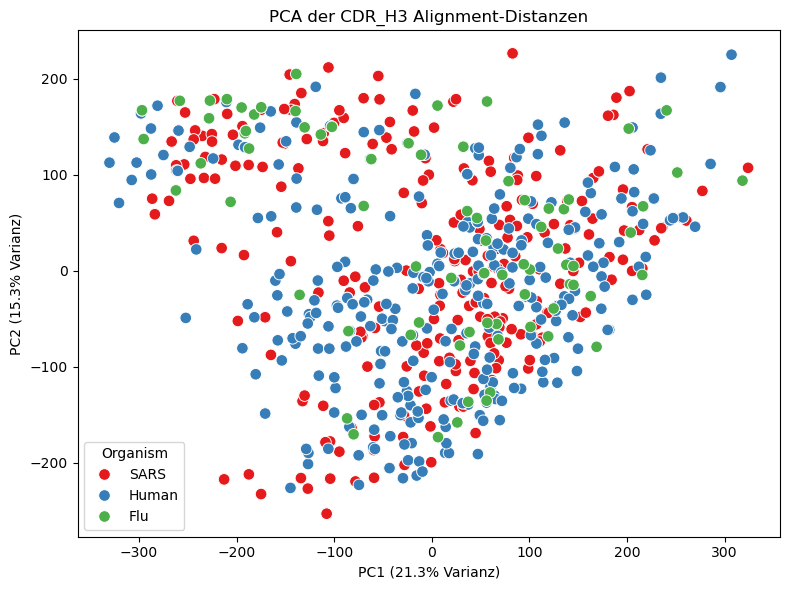

In [7]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Alignment-Score-Matrix einlesen
# Falls du schon `matrix_results` aus deinem Code hast, kannst du stattdessen direkt:
# score_df = matrix_results["CDR_H2"]

score_df = pd.read_csv("cdr_h3_alignment_matrix.tsv", sep="\t", index_col=0)

# 2️⃣ Distanzmatrix berechnen
# Wir nehmen als Distanz: max(Score) - Score
max_score = score_df.values.max()
distance_matrix = max_score - score_df.values

# 3️⃣ PCA berechnen
pca = PCA(n_components=2)
pcs = pca.fit_transform(distance_matrix)

# 4️⃣ DataFrame für Plot vorbereiten
ids = score_df.index.tolist()
organisms = [id.split("_")[0] for id in ids]

pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "ID": ids,
    "Organism": organisms
})

# 5️⃣ Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Organism",  # Farben nach Organismus
    palette="Set1",
    s=70
)
plt.title("PCA der CDR_H3 Alignment-Distanzen")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.legend(title="Organism")
plt.tight_layout()
plt.show()


### K-means

de cuál ahhhhhh??????????????


In [ ]:
from sklearn.cluster import KMeans

# Wir nehmen dieselben PCs wie oben
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(pca_df[["PC1", "PC2"]])

# Labels zu DataFrame hinzufügen
pca_df["Cluster"] = labels

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=70
)
plt.title("k-Means Clustering der PCA (CDR_H2)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.tight_layout()
plt.show()


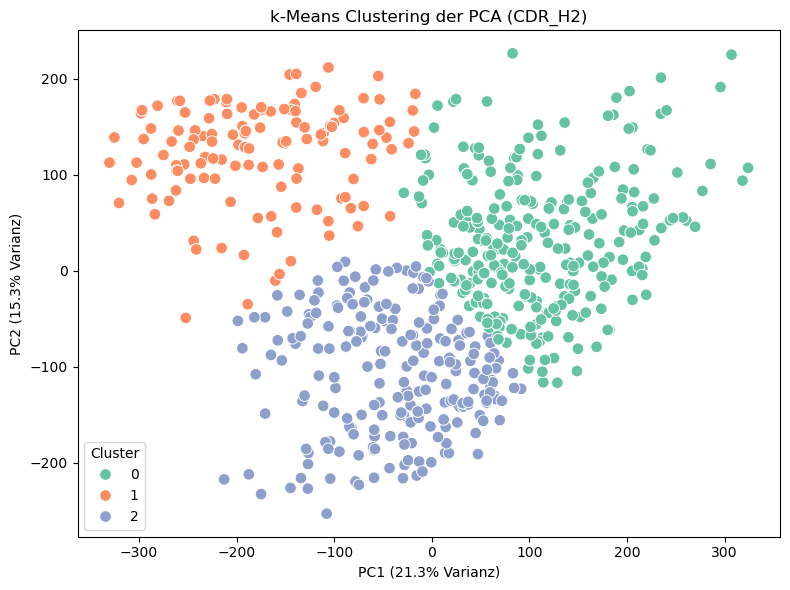

In [8]:
from sklearn.cluster import KMeans

# Wir nehmen dieselben PCs wie oben
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(pca_df[["PC1", "PC2"]])

# Labels zu DataFrame hinzufügen
pca_df["Cluster"] = labels

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=70
)
plt.title("k-Means Clustering der PCA (CDR_H2)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.tight_layout()
plt.show()


### Hierarchisches Clsutering


### MDS der CDR Distanzen 